# Malware Traffic Classification — EDA & Preprocessing
Two-stage hierarchical classification, matching the project scope ("Open-Set Malware Traffic
Classification using 1D-CNNs and JA4 Fingerprinting"):

- **Stage 1 — benign vs. malware** (binary)
- **Stage 2 — malware family**: Emotet vs. Trickbot (closed-set, known classes), with Dreambot
  held out as the open-set **unknown** class for Stage 2 evaluation only.

**Notebook conventions used below:**
- Every step that filters/drops rows explains *why* in a comment.
- Duplicate checking happens on the **raw** feature set, before feature selection, so we don't
  accidentally call two genuinely-different flows "duplicates" just because they match on a
  reduced column set.
- The Dreambot subset is **saved off, not discarded** — it's the planned open-set unknown class
  for Stage 2 and will be needed again later without re-touching this notebook.
- Run this top-to-bottom (`Restart Kernel & Run All`) before trusting any printed numbers —
  cells are written to be safely re-run in order.


In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

import re, os

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
DATA_PATH = "final.csv"
OUT_DIR = "processed"
os.makedirs(OUT_DIR, exist_ok=True)

df_raw = pd.read_csv(DATA_PATH)

print("Raw shape:", df_raw.shape)
print(df_raw["label"].value_counts())
df_raw.head()


Raw shape: (39670, 89)
label
emotet           13977
benign           11538
trickbot         10904
minor_project     3192
dreambot            59
Name: count, dtype: int64


,dst_port,protocol,duration,total_bytes,total_packets,fwd_pkts,fwd_bytes,fwd_pkt_len_mean,fwd_pkt_len_std,fwd_pkt_len_min,fwd_pkt_len_max,fwd_iat_mean,fwd_iat_std,fwd_iat_min,fwd_iat_max,fwd_syn,fwd_ack,fwd_fin,fwd_rst,fwd_psh,fwd_urg,bwd_pkts,bwd_bytes,bwd_pkt_len_mean,bwd_pkt_len_std,bwd_pkt_len_min,bwd_pkt_len_max,bwd_iat_mean,bwd_iat_std,bwd_iat_min,bwd_iat_max,bwd_syn,bwd_ack,bwd_fin,bwd_rst,bwd_psh,bwd_urg,bytes_per_second,packets_per_second,fwd_bytes_per_second,bwd_bytes_per_second,down_up_ratio,flow_pkt_asymmetry,flow_byte_asymmetry,pkt_len_mean,pkt_len_std,pkt_len_min,pkt_len_max,pkt_len_q1,pkt_len_q3,pkt_len_skew,pkt_len_entropy,small_pkt_ratio,large_pkt_ratio,iat_mean,iat_std,iat_min,iat_max,burstiness,burst_count,mean_burst_duration,direction_switches,src_port_ephemeral,is_well_known_dst_port,is_complete_handshake,handshake_ratio,has_tls,tls_version,tls_cipher_count,tls_ext_count,ja4_fingerprint,ja4_tls_ver_num,ja4_cipher_count,ja4_ext_count,ja4_sni_present,ja4_has_alpn,ja3_fingerprint,fingerprint_source,has_sni,cipher_suite,dns_query_count,dns_query_types,dns_unique_queries,http_request_count,http_unique_hosts,http_unique_uris,label,fingerprint_final,fingerprint_method
0,443,TCP,0.414215,4391,18,9,1069,118.7778,96.0599,54.0,331.0,0.051777,0.060601,0.000052,0.153464,1,7,1,2,3,0,9,3322,369.1111,469.2259,54.0,1514.0,0.051752,0.060687,0.000019,0.153806,1,9,1,0,4,0,10600.7750,43.4557,2580.7853,8019.9896,3.1047,0.0000,-0.5131,243.9444,361.0636,54.0,1514.0,54.0,210.5,2.5105,2.7255,0.5556,0.0556,0.024366,0.048840,0.000015,0.153464,2.0045,1,0.414215,10,1,1,1,0.1111,1,NaN,21,3,t12i210300_b973bfd88a0e_c08b0bbc99a6,12,21,3,0,0,5079c37250d628519709602286e00194,ja4,0,0x3c,0,0,0,0,0,0,minor_project,t12i210300_b973bfd88a0e_c08b0bbc99a6,ja4
1,443,TCP,0.058407,4369,17,9,1101,122.3333,98.8849,54.0,331.0,0.007301,0.008833,0.000067,0.021247,1,7,1,2,3,0,8,3268,408.5000,483.4576,54.0,1514.0,0.008309,0.009122,0.000015,0.021010,1,8,1,0,4,0,74802.6778,291.0610,18850.4803,55952.1975,2.9655,0.0588,-0.4960,257.0000,368.1982,54.0,1514.0,54.0,220.0,2.4086,2.8138,0.5294,0.0588,0.003650,0.007186,0.000015,0.021010,1.9686,1,0.058407,10,1,1,1,0.1176,1,NaN,21,3,t12i210300_b973bfd88a0e_c08b0bbc99a6,12,21,3,0,0,5079c37250d628519709602286e00194,ja4,0,0x3c,0,0,0,0,0,0,minor_project,t12i210300_b973bfd88a0e_c08b0bbc99a6,ja4
2,443,TCP,0.038559,4261,15,8,1047,130.8750,101.7048,54.0,331.0,0.005508,0.008076,0.000184,0.021922,1,7,0,1,3,0,7,3214,459.1429,496.5922,54.0,1514.0,0.006356,0.008503,0.000025,0.021695,1,7,1,0,4,0,110505.9779,389.0142,27153.1938,83352.7840,3.0668,0.0667,-0.5086,284.0667,383.9515,54.0,1514.0,54.0,275.5,2.2152,2.9996,0.4667,0.0667,0.002754,0.006277,0.000025,0.021695,2.2790,1,0.038559,8,1,1,1,0.1333,1,NaN,21,3,t12i210300_b973bfd88a0e_c08b0bbc99a6,12,21,3,0,0,5079c37250d628519709602286e00194,ja4,0,0x3c,0,0,0,0,0,0,minor_project,t12i210300_b973bfd88a0e_c08b0bbc99a6,ja4
3,443,TCP,0.037885,4261,15,8,1047,130.8750,101.7048,54.0,331.0,0.005412,0.008064,0.000093,0.021719,1,7,1,1,3,0,7,3214,459.1429,496.5922,54.0,1514.0,0.006284,0.008478,0.000037,0.021553,1,7,1,0,4,0,112471.9546,395.9351,27636.2677,84835.6869,3.0668,0.0667,-0.5086,284.0667,383.9515,54.0,1514.0,54.0,275.5,2.2152,2.9996,0.4667,0.0667,0.002706,0.006265,0.000019,0.021553,2.3151,1,0.037885,8,1,1,1,0.1333,1,NaN,21,3,t12i210300_b973bfd88a0e_c08b0bbc99a6,12,21,3,0,0,5079c37250d628519709602286e00194,ja4,0,0x3c,0,0,0,0,0,0,minor_project,t12i210300_b973bfd88a0e_c08b0bbc99a6,ja4
4,443,TCP,0.037970,4261,15,8,1047,130.8750,101.7048,54.0,331.0,0.005424,0.008087,0.000155,0.021934,1,7,1,1,3,0,7,3214,459.1429,496.5922,54.0,1514.0,0.006299,0.008477,0.000036,0.021707,1,7,0,0,4,0,112220.1738,395.0487,27574.4008,84645.7730,3.0668,0.0667,-0.5086,284.0667,383.9515,54.0,1514.0,54.0,275.5,2.2152,2.9996,0.4667,0.0667,0.002712,0.006267,0.000036,0.021707,2.3109,1,0.037970,10,1,1,1,0.1333,1,NaN,21,3,t12i210300_b973bfd88a0e_c08b0bbc99a6,12,21,3,0,0,5079c37250d628519709602286e00194,ja4,0,0x3c,0,0,0,0,0,0,minor_pr

## 1. Raw-level cleaning

Deduplication and inf/NaN checks happen **here**, on the full 89-column raw frame — not after
feature selection. If we dedupe on the reduced feature set instead, two flows that differ only
in a column we're about to drop (e.g. timestamps, exact byte counts) would incorrectly look
identical and get merged.

In [28]:
# --- Exact duplicate rows on the raw feature set ---
n_dupes_raw = df_raw.duplicated().sum()
print("Exact duplicate rows (raw, all 89 cols):", n_dupes_raw)
df_raw = df_raw.drop_duplicates().reset_index(drop=True)
print("Shape after raw dedup:", df_raw.shape)

# --- Inf check ---
# bytes_per_second / packets_per_second / *_bytes_per_second are almost certainly
# bytes-or-packets divided by duration. Any flow with duration == 0 (single-packet flows
# are common) produces inf, which isnull() will NOT catch and which will silently break
# MinMaxScaler / StandardScaler downstream.
numeric_raw = df_raw.select_dtypes(include=[np.number])
inf_counts = np.isinf(numeric_raw).sum()
inf_counts = inf_counts[inf_counts > 0]
print("\nColumns containing inf values:")
print(inf_counts if len(inf_counts) else "  none")

if len(inf_counts):
    inf_mask = np.isinf(numeric_raw[inf_counts.index]).any(axis=1)
    print(f"\nRows with at least one inf value: {inf_mask.sum()} — dropping them.")
    df_raw = df_raw.loc[~inf_mask].reset_index(drop=True)

# --- Missing values ---
na_counts = df_raw.isnull().sum().sort_values(ascending=False)
na_counts = na_counts[na_counts > 0]
print("\nColumns with missing values:")
print(na_counts if len(na_counts) else "  none")
# tls_version is entirely null in the raw dump (0 non-null in df.info()) — confirm and drop it
# outright rather than carrying a 100%-empty column through feature selection.
if "tls_version" in df_raw.columns and df_raw["tls_version"].notna().sum() == 0:
    print("\n'tls_version' is 100% null — dropping the column.")
    df_raw = df_raw.drop(columns=["tls_version"])

Exact duplicate rows (raw, all 89 cols): 3178
Shape after raw dedup: (36492, 89)

Columns containing inf values:
  none

Columns with missing values:
tls_version    36492
dtype: int64

'tls_version' is 100% null — dropping the column.


## 2. Label handling

Five raw labels are present. The project needs a **two-stage hierarchical classifier**, not a
flat multiclass one, so labels are handled accordingly:

- `minor_project` — leftover self-generated/test traffic, not a real malware family or benign
  traffic. Dropped entirely; doesn't belong in either stage.
- `dreambot` — **kept**, but split off into its own dataframe (`df_dreambot`) and saved to disk.
  It's the planned open-set **unknown malware** class, held out for **Stage 2 evaluation only**
  (it's malware, not benign, but withholding it from training entirely keeps the open-set holdout
  genuinely untouched).
- `benign` — **kept in the working frame.** This is *not* leftover data to drop — Stage 1 detects
  benign vs. malware traffic, so benign flows are a required class.
- `emotet` / `trickbot` — the two known malware families. Used for **Stage 2**: classification
  among these two (closed-set), with JA4 as the primary feature, open-set-rejecting anything that
  doesn't look like either.

**Stage 1 target:** `benign` vs. everything else (`emotet` + `trickbot`), built from all rows.
**Stage 2 target:** `emotet` vs. `trickbot` only, built from the malware subset of rows.


In [29]:
print("All labels present:", df_raw["label"].unique().tolist())

# Leftover test data — not a malware family, not benign traffic, not needed in either stage
n_before = len(df_raw)
df_raw = df_raw[df_raw["label"] != "minor_project"].reset_index(drop=True)
print(f"Dropped 'minor_project': {n_before - len(df_raw)} rows removed.")

# Dreambot = open-set unknown, held out for Stage 2 (malware-family) evaluation only.
# Save it off untouched (raw columns) so the Stage 2 eval notebook can pick it up without
# re-running this whole pipeline. It is excluded from BOTH stages' training data here.
df_dreambot = df_raw[df_raw["label"] == "dreambot"].reset_index(drop=True)
df_raw = df_raw[df_raw["label"] != "dreambot"].reset_index(drop=True)

dreambot_path = os.path.join(OUT_DIR, "dreambot_openset_unknown_raw.csv")
df_dreambot.to_csv(dreambot_path, index=False)
print(f"Dreambot subset: {df_dreambot.shape[0]} rows -> saved to {dreambot_path}")

# benign is KEPT here (required for Stage 1 — do not drop it like minor_project).
print("\nWorking label counts (benign + emotet + trickbot):")
print(df_raw["label"].value_counts())
print(df_raw["label"].value_counts(normalize=True).round(4))

df = df_raw.copy()  # `df` = working frame for both stages


All labels present: ['minor_project', 'dreambot', 'emotet', 'trickbot', 'benign']
Dropped 'minor_project': 3192 rows removed.
Dreambot subset: 59 rows -> saved to processed\dreambot_openset_unknown_raw.csv

Working label counts (benign + emotet + trickbot):
label
emotet      13977
trickbot    10904
benign       8360
Name: count, dtype: int64
label
emotet      0.4205
trickbot    0.3280
benign      0.2515
Name: proportion, dtype: float64


## 3. Feature selection

Same feature list as before — dropping raw IP/timestamp-style columns is intentional, so the
model learns flow *behavior* rather than memorizing specific hosts.

⚠️ **Known limitation, flagged not fixed:** there is no session/capture/source-host identifier
anywhere in this dataset (no `src_ip`, no capture-file id). That means we currently have no way
to do a *grouped* train/test split, and flows from the same infected host in the same capture
could end up split across train and test, inflating accuracy. If you can get the extractor to
emit a `capture_id` or `src_ip` column (even hashed/anonymized) in a future pass, add a grouped
split using `GroupShuffleSplit`. Until then, treat the accuracy number from this pipeline as an
optimistic upper bound, not a generalization estimate — the ablation/leakage checks in Section 4
matter more than the raw accuracy.

In [30]:
features = [
    "protocol", "duration", "total_bytes", "total_packets",
    "bytes_per_second", "packets_per_second",
    "pkt_len_mean", "pkt_len_std",
    "iat_mean", "iat_std", "burstiness", "burst_count",
    "is_complete_handshake", "has_tls",
    "tls_cipher_count", "tls_ext_count",
    "ja4_fingerprint", "ja4_tls_ver_num", "ja4_cipher_count", "ja4_ext_count",
    "ja4_sni_present", "ja4_has_alpn", "ja3_fingerprint",
    "dns_query_count", "dns_unique_queries",
    "http_request_count", "http_unique_hosts",
    "label",
]

missing_cols = [c for c in features if c not in df.columns]
print("Missing columns:", missing_cols if missing_cols else "none")

df_selected = df[features].copy()
print("Selected shape:", df_selected.shape)
df_selected.head()

Missing columns: none
Selected shape: (33241, 28)


,protocol,duration,total_bytes,total_packets,bytes_per_second,packets_per_second,pkt_len_mean,pkt_len_std,iat_mean,iat_std,burstiness,burst_count,is_complete_handshake,has_tls,tls_cipher_count,tls_ext_count,ja4_fingerprint,ja4_tls_ver_num,ja4_cipher_count,ja4_ext_count,ja4_sni_present,ja4_has_alpn,ja3_fingerprint,dns_query_count,dns_unique_queries,http_request_count,http_unique_hosts,label
0,TCP,0.054227,384,5,7081.3432,92.2050,76.8,34.0259,0.013557,0.023228,1.7134,1,0,1,12,2,t10i120200_d94e65cdb899_33a13ba74d1c,10,12,2,0,0,a1834ba4714ad4767c0eaa94a9f32dd2,0,0,0,0,emotet
1,TCP,0.000531,416,5,783427.4953,9416.1959,83.2,46.7093,0.000133,0.000092,0.6950,1,0,1,12,2,t10i120200_d94e65cdb899_33a13ba74d1c,10,12,2,0,0,a1834ba4714ad4767c0eaa94a9f32dd2,0,0,0,0,emotet
2,TCP,0.000530,416,5,784905.6603,9433.9623,83.2,46.7093,0.000133,0.000088,0.6624,1,0,1,12,2,t10i120200_d94e65cdb899_33a13ba74d1c,10,12,2,0,0,a1834ba4714ad4767c0eaa94a9f32dd2,0,0,0,0,emotet
3,TCP,0.000576,408,5,708333.3333,8680.5556,81.6,47.3354,0.000144,0.000076,0.5253,1,0,1,12,2,t10i120200_d94e65cdb899_33a13ba74d1c,10,12,2,0,0,a1834ba4714ad4767c0eaa94a9f32dd2,0,0,0,0,emotet
4,TCP,0.000991,416,5,419778.0020,5045.4087,83.2,46.7093,0.000248,0.000082,0.3293,1,0,1,12,2,t10i120200_d94e65cdb899_33a13ba74d1c,10,12,2,0,0,a1834ba4714ad4767c0eaa94a9f32dd2,0,0,0,0,emotet


## 4. EDA

### 4.1 Class balance

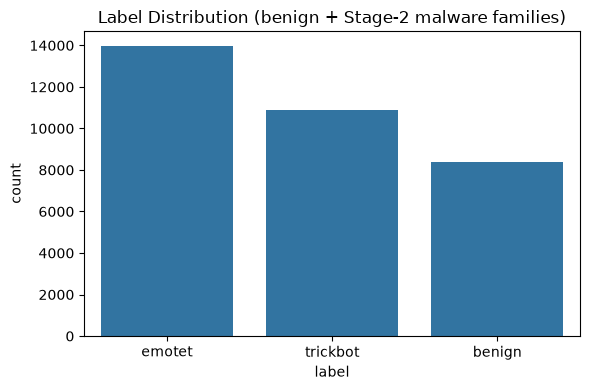

In [31]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_selected, x="label", order=df_selected["label"].value_counts().index)
plt.title("Label Distribution (benign + Stage-2 malware families)")
plt.tight_layout()
plt.show()


### 4.2 Fingerprint leakage check (per stage)

Checked **separately per stage** — they're different risks:

- **Stage 1 (benign vs. malware):** JA3/JA4 trivially separating benign from malware traffic is
  *expected*, not a leakage problem — malware C2 infrastructure and benign services genuinely use
  different TLS client configurations. Reported for visibility, not flagged as a concern on its own.
- **Stage 2 (emotet vs. trickbot):** this is the leakage risk that actually matters. If JA4
  fingerprints map almost 1:1 to a single malware family, the Stage 2 model can trivially "solve"
  the dataset by memorizing TLS client signatures instead of learning malware traffic behavior,
  and it will fail on any sample using a different TLS stack.


############ STAGE 1: benign vs malware ############

=== ja3_fingerprint: 2326 unique values, 33241 flows ===
stage1_label                      benign  malware  total  max_class_share
ja3_fingerprint                                                          
a1834ba4714ad4767c0eaa94a9f32dd2       0    24637  24637              1.0
8d1f0b862e51e66482768729950de3ae    2165        0   2165              1.0
fe2800ac08c163f131d1b4f9ef312a77    1096        0   1096              1.0
004bf73563645cc1faefe99886ed32eb     983        0    983              1.0
e41de9f02b520e4df320984cae5b1147     327        0    327              1.0
d76a5a80b4bb0c75ac45782b0b53da91     162        0    162              1.0
5887cacb9fbfe50f894f11fcc87a83ff       0      159    159              1.0
fae0e5d973c96ae1888b99538efa0363     133        0    133              1.0
d871d02cecbde59abbf8f4806134addf     131        0    131              1.0
c2a3f86b971cc10417d574b20c9ade7a     128        0    128              1.0
8

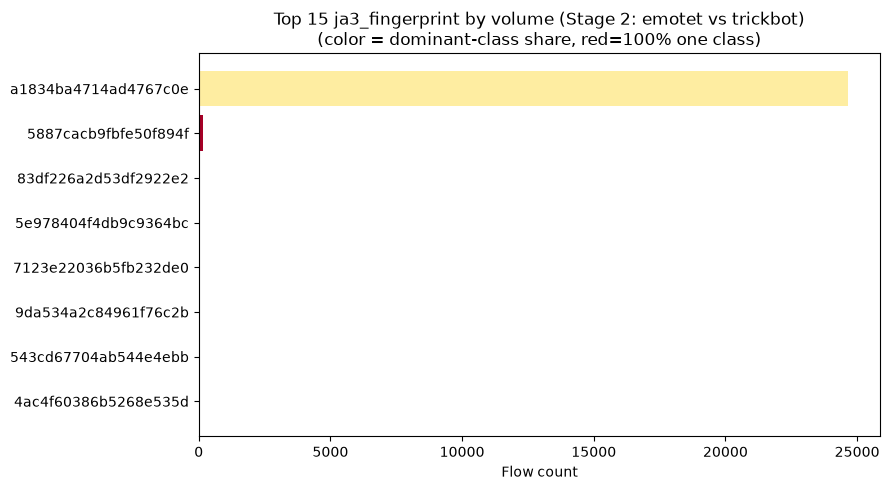


=== ja4_fingerprint: 8 unique values, 24881 flows ===
label                                 emotet  trickbot  total  max_class_share
ja4_fingerprint                                                               
t10i120200_d94e65cdb899_33a13ba74d1c   13736     10901  24637         0.557535
t12d210400_b973bfd88a0e_2ca883e602c2     159         0    159         1.000000
t12d1908h2_d83cc789557e_8ebfdaddfa31      57         0     57         1.000000
t12d190700_d83cc789557e_8ebfdaddfa31      15         0     15         1.000000
t12d1908h2_d83cc789557e_a03104ec44d2       7         0      7         1.000000
ts3i040000_79bb1f42e07b_e3b0c44298fc       0         3      3         1.000000
t12d190600_d83cc789557e_d7ff7c8fd4af       2         0      2         1.000000
t12d210600_76e208dd3e22_d7ff7c8fd4af       1         0      1         1.000000

 threshold  n_fingerprints   flows_covered  pct_of_flows
      0.90               7             244         1.0%
      0.95               7             24

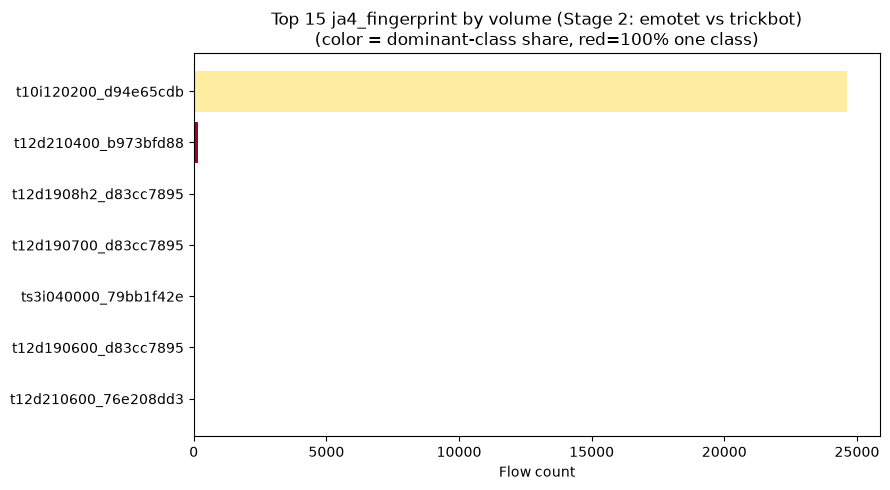

In [32]:
# --- Stage 1: benign vs malware ---
df_stage1 = df_selected.copy()
df_stage1["stage1_label"] = np.where(df_stage1["label"] == "benign", "benign", "malware")

print("############ STAGE 1: benign vs malware ############")
for fp_col in ["ja3_fingerprint", "ja4_fingerprint"]:
    ct = pd.crosstab(df_stage1[fp_col], df_stage1["stage1_label"])
    ct["total"] = ct.sum(axis=1)
    ct["max_class_share"] = ct[["benign", "malware"]].max(axis=1) / ct["total"]
    ct = ct.sort_values("total", ascending=False)
    rows_total = ct["total"].sum()

    print(f"\n=== {fp_col}: {df_stage1[fp_col].nunique()} unique values, {rows_total} flows ===")
    print(ct.head(15))
    print(f"\n{'threshold':>10} {'n_fingerprints':>15} {'flows_covered':>15} {'pct_of_flows':>13}")
    for thresh in [0.90, 0.95, 0.98, 1.00]:
        mask = ct["max_class_share"] >= thresh
        n = mask.sum()
        rows = ct.loc[mask, "total"].sum()
        print(f"{thresh:>10.2f} {n:>15} {rows:>15} {rows / rows_total:>12.1%}")

# --- Stage 2: emotet vs trickbot only (this is the leakage risk that matters most) ---
df_stage2 = df_selected[df_selected["label"].isin(["emotet", "trickbot"])].copy()

print("\n\n############ STAGE 2: emotet vs trickbot (malware family) ############")
for fp_col in ["ja3_fingerprint", "ja4_fingerprint"]:
    ct = pd.crosstab(df_stage2[fp_col], df_stage2["label"])
    ct["total"] = ct.sum(axis=1)
    ct["max_class_share"] = ct[["emotet", "trickbot"]].max(axis=1) / ct["total"]
    ct = ct.sort_values("total", ascending=False)
    rows_total = ct["total"].sum()

    print(f"\n=== {fp_col}: {df_stage2[fp_col].nunique()} unique values, {rows_total} flows ===")
    print(ct.head(15))
    print(f"\n{'threshold':>10} {'n_fingerprints':>15} {'flows_covered':>15} {'pct_of_flows':>13}")
    for thresh in [0.90, 0.95, 0.98, 1.00]:
        mask = ct["max_class_share"] >= thresh
        n = mask.sum()
        rows = ct.loc[mask, "total"].sum()
        print(f"{thresh:>10.2f} {n:>15} {rows:>15} {rows / rows_total:>12.1%}")

    top = ct.head(15).reset_index()
    plt.figure(figsize=(9, 5))
    plt.barh(top[fp_col].astype(str).str[:20], top["total"],
              color=plt.cm.RdYlGn_r(top["max_class_share"]))
    plt.xlabel("Flow count")
    plt.title(f"Top 15 {fp_col} by volume (Stage 2: emotet vs trickbot)\n"
              f"(color = dominant-class share, red=100% one class)")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


### 4.3 Per-feature distributions by class

Boxplots split by label show class separability directly — the correlation heatmap alone won't
tell you this. Byte/timing features in network traffic are typically heavy-tailed, so these are
plotted on a log scale.

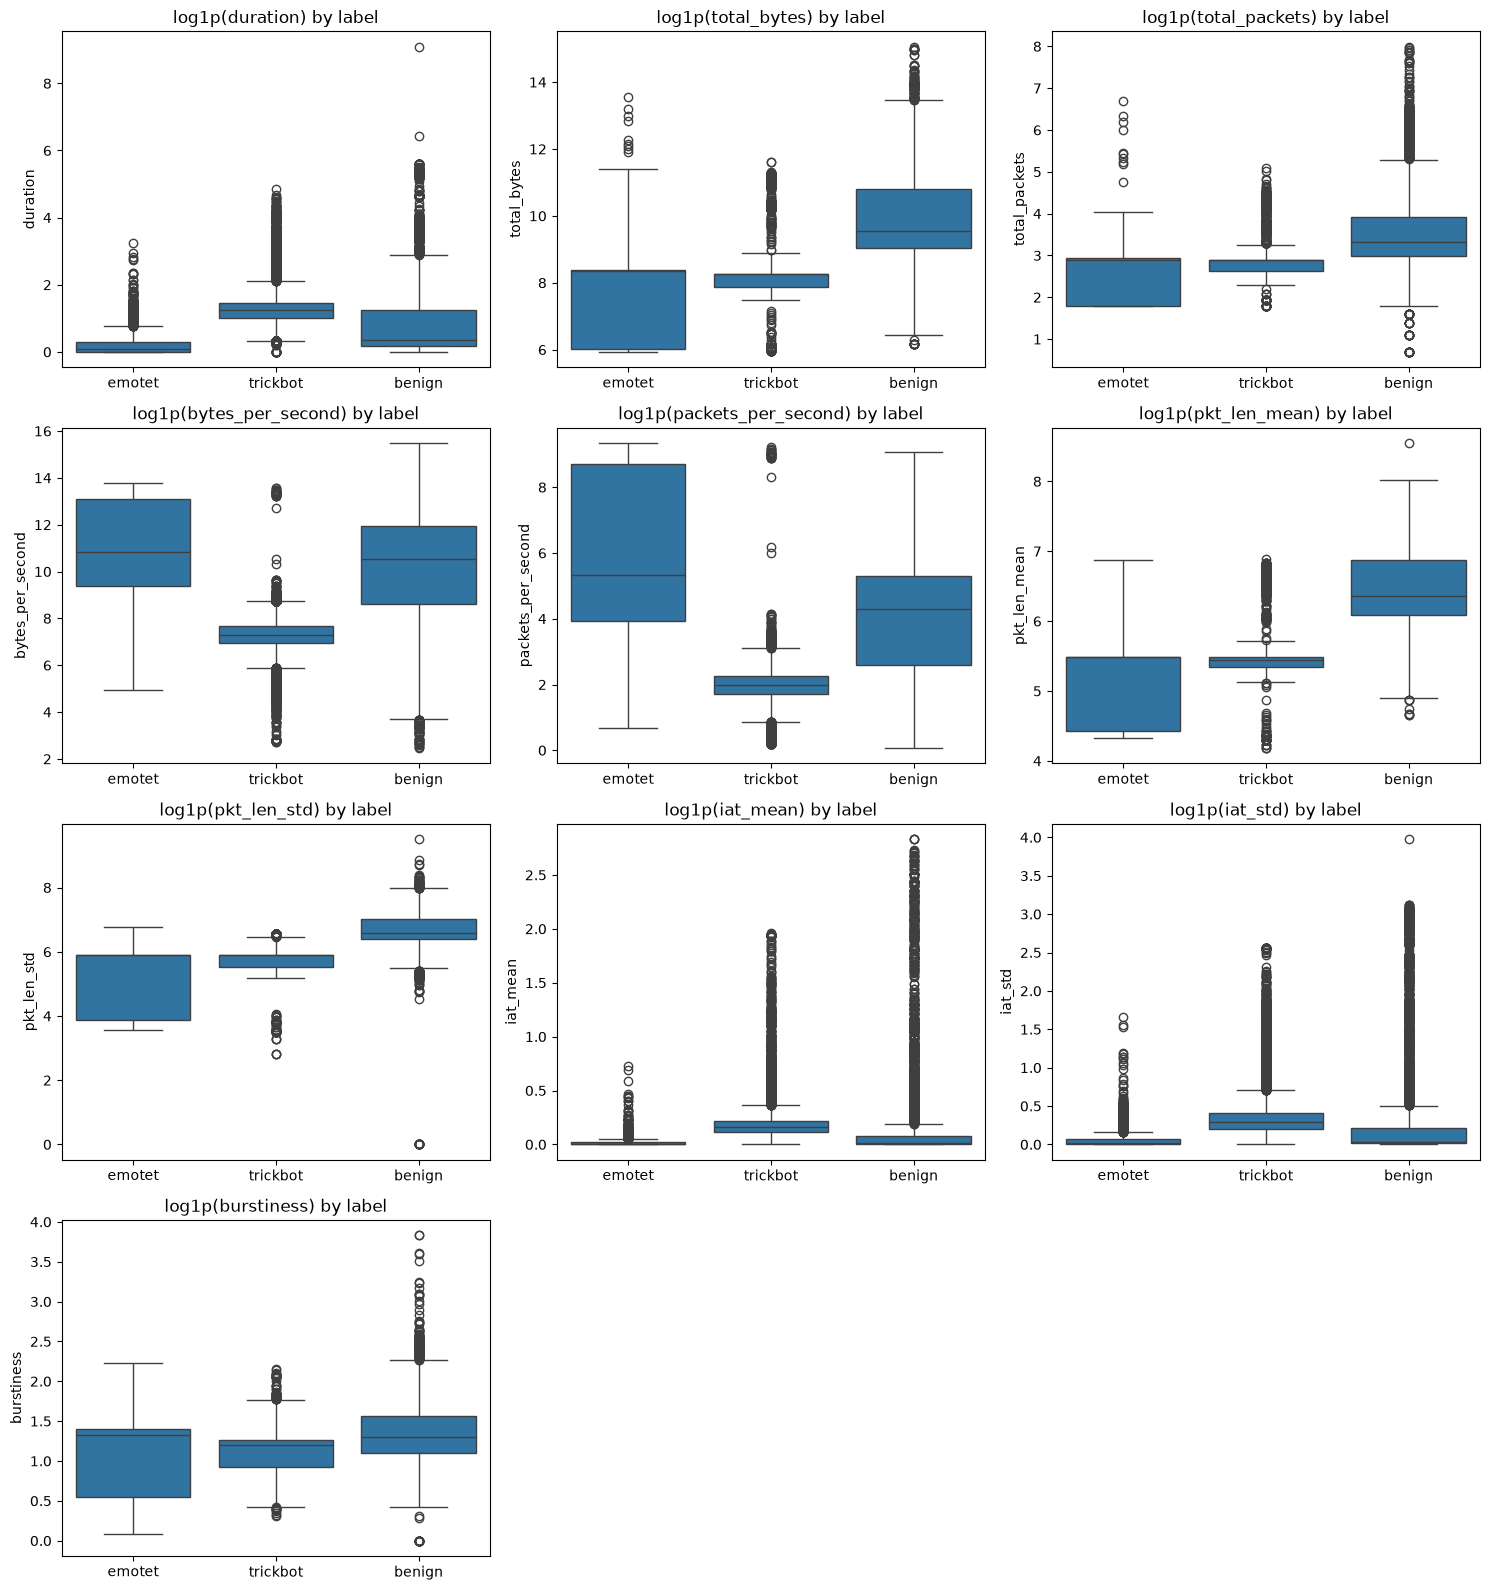

In [33]:
log_candidates = ["duration", "total_bytes", "total_packets",
                   "bytes_per_second", "packets_per_second",
                   "pkt_len_mean", "pkt_len_std", "iat_mean", "iat_std", "burstiness"]
log_candidates = [c for c in log_candidates if c in df_selected.columns]

n = len(log_candidates)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(log_candidates):
    ax = axes[i]
    plot_df = df_selected[[col, "label"]].copy()
    # log1p so zero values don't break the log scale
    plot_df[col] = np.log1p(plot_df[col].clip(lower=0))
    sns.boxplot(data=plot_df, x="label", y=col, ax=ax)
    ax.set_title(f"log1p({col}) by label")
    ax.set_xlabel("")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 4.4 Correlation heatmap (numeric features only)

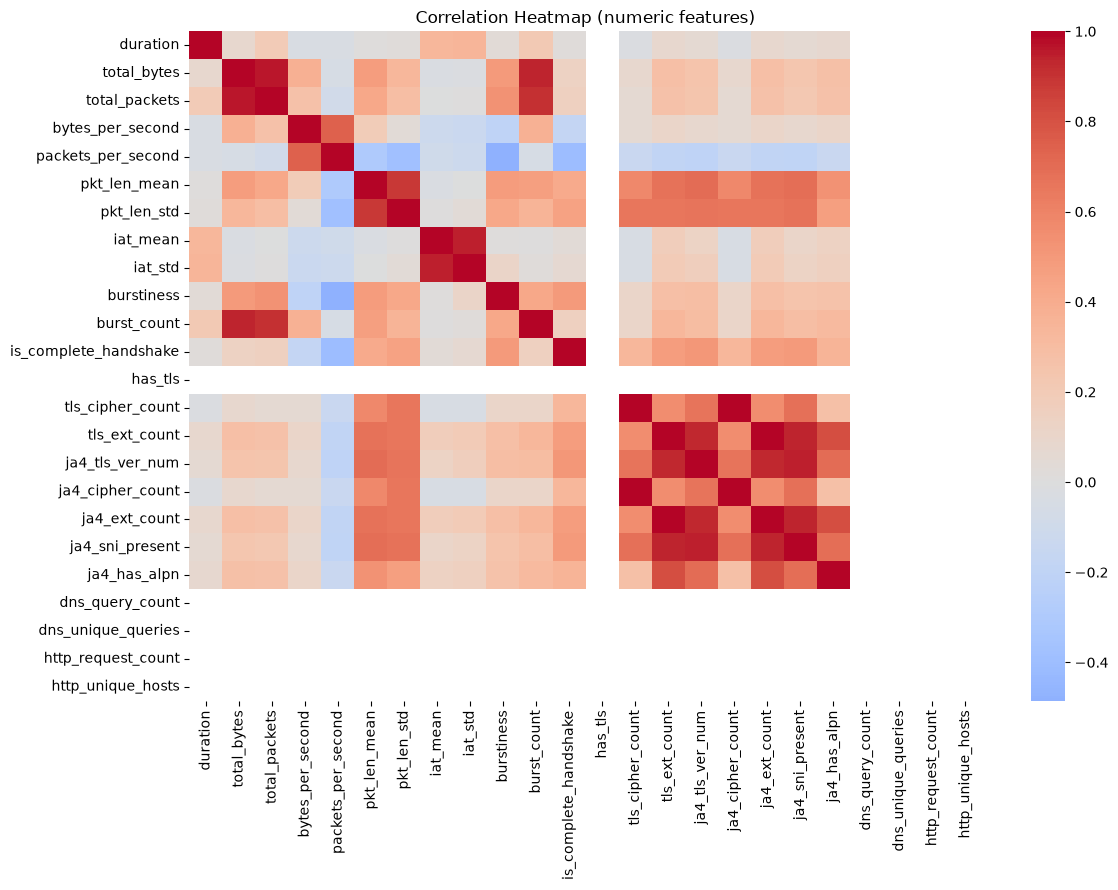

In [34]:
numeric_cols = df_selected.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(12, 9))
corr = df_selected[numeric_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (numeric features)")
plt.tight_layout()
plt.show()

### 4.5 Feature ↔ label association ranking

Quick ANOVA F-score and mutual information ranking against the label, to sanity-check *which*
features are actually carrying signal before training a CNN on all of them. If the fingerprint
columns dominate this ranking, that lines up with the leakage check above and is worth reporting
as a limitation, not just training around silently.

c:\Users\lenovo\OneDrive\Desktop\minor project\venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [12 20 21 22 23] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\lenovo\OneDrive\Desktop\minor project\venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


              feature       f_score  mutual_info
          pkt_len_std  15375.498224     1.015526
          total_bytes   1189.794025     1.002111
         pkt_len_mean  17057.366262     0.992451
             duration     95.114360     0.723128
   packets_per_second   4270.236147     0.711855
             iat_mean    637.734378     0.708523
          burst_count   1765.690893     0.703372
     bytes_per_second   2151.097920     0.681538
              iat_std    869.333801     0.625906
        total_packets   1131.337465     0.620977
     tls_cipher_count  13528.360660     0.574764
     ja4_cipher_count  13528.360660     0.568950
      ja4_tls_ver_num 343790.744600     0.559928
        ja4_ext_count 135078.277731     0.554182
        tls_ext_count 135078.277731     0.550312
      ja4_sni_present 129746.049662     0.463302
           burstiness   1569.708612     0.446588
is_complete_handshake  18265.472171     0.324091
         ja4_has_alpn  16528.534534     0.238657
      dns_query_coun

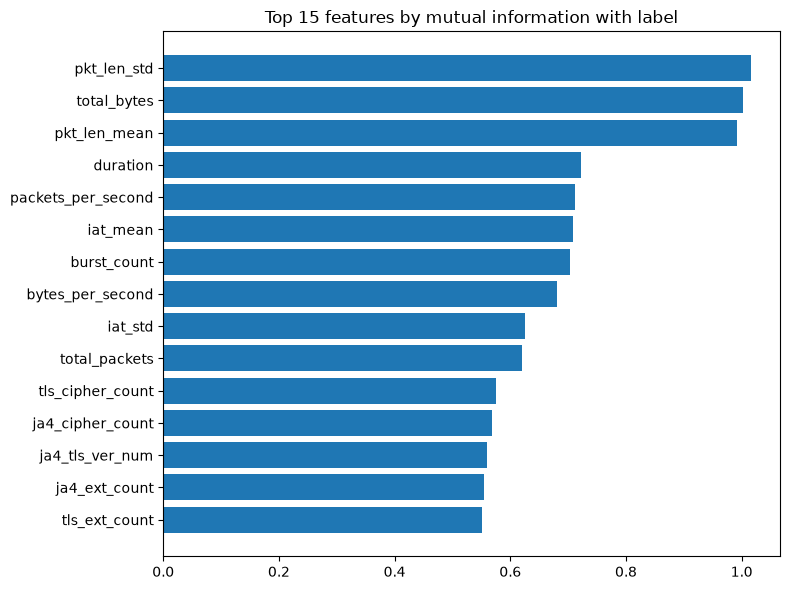

In [35]:
X_numeric = df_selected[numeric_cols].fillna(df_selected[numeric_cols].median())
y_tmp = df_selected["label"]

f_scores, _ = f_classif(X_numeric, y_tmp)
mi_scores = mutual_info_classif(X_numeric, y_tmp, random_state=RANDOM_STATE)

assoc = pd.DataFrame({
    "feature": numeric_cols,
    "f_score": f_scores,
    "mutual_info": mi_scores,
}).sort_values("mutual_info", ascending=False)

print(assoc.to_string(index=False))

plt.figure(figsize=(8, 6))
top = assoc.head(15).sort_values("mutual_info")
plt.barh(top["feature"], top["mutual_info"])
plt.title("Top 15 features by mutual information with label")
plt.tight_layout()
plt.show()

## 5. JA4 structural decomposition + Stage 1 / Stage 2 targets

Same JA4 decomposition approach as before — split the JA4 string into its real substructure
rather than treating it as one opaque categorical ID. Feature engineering is done **once** on
the full working frame (`benign` + `emotet` + `trickbot`); the two stages then reuse the same
feature columns, just with different targets and row subsets:

- `X_stage1` / `y_stage1` — all rows, target = benign vs. malware.
- `X_stage2` / `y_stage2` — malware rows only, target = emotet vs. trickbot.


In [36]:
stage1_label = np.where(df_selected["label"] == "benign", "benign", "malware")

X = df_selected.drop(columns=["label"]).copy()

for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        X[col] = X[col].fillna(X[col].median())
    else:
        X[col] = X[col].fillna("unknown")

if "ja4_fingerprint" in X.columns:
    X["has_ja4"] = (X["ja4_fingerprint"] != "unknown").astype(int)
if "ja3_fingerprint" in X.columns:
    X["has_ja3"] = (X["ja3_fingerprint"] != "unknown").astype(int)

PROTOCOL_VOCAB = {"t": 0, "q": 1}
TLS_VERSION_VOCAB = {
    "13": 0, "12": 1, "11": 2, "10": 3,
    "s3": 4, "s2": 5, "s1": 6, "d3": 7, "d2": 8, "d1": 9, "00": 10,
}
ALPN_VOCAB = {"00": 0, "h1": 1, "h2": 2, "h3": 3, "ht": 4, "d2": 5}
N_HASH_BUCKETS = 256

def parse_ja4(fp: str):
    if not isinstance(fp, str) or "_" not in fp or fp == "unknown":
        return None
    parts = fp.split("_")
    if len(parts) != 3 or len(parts[0]) < 10:
        return None
    a, b, c = parts
    return {
        "protocol": PROTOCOL_VOCAB.get(a[0], -1),
        "tls_version": TLS_VERSION_VOCAB.get(a[1:3], -1),
        "sni_present": 1 if a[3] == "d" else 0,
        "cipher_count": int(re.sub(r"\D", "", a[4:6]) or 0),
        "ext_count": int(re.sub(r"\D", "", a[6:8]) or 0),
        "alpn": ALPN_VOCAB.get(a[8:10], -1),
        "cipher_hash_bucket": int(b, 16) % N_HASH_BUCKETS if b else 0,
        "ext_hash_bucket": int(c, 16) % N_HASH_BUCKETS if c else 0,
    }

JA4_SUBFEATURES = [
    "ja4_protocol", "ja4_tls_version_parsed", "ja4_sni_present_parsed",
    "ja4_cipher_count_parsed", "ja4_ext_count_parsed", "ja4_alpn",
    "ja4_cipher_hash_bucket", "ja4_ext_hash_bucket",
]
KEYS = ["protocol", "tls_version", "sni_present", "cipher_count",
        "ext_count", "alpn", "cipher_hash_bucket", "ext_hash_bucket"]

if "ja4_fingerprint" in X.columns:
    parsed = X["ja4_fingerprint"].map(parse_ja4)
    for feat_name, key in zip(JA4_SUBFEATURES, KEYS):
        X[feat_name] = parsed.map(lambda p, k=key: p[k] if p else -1)
    X = X.drop(columns=["ja4_fingerprint"])
    print(f"ja4_fingerprint -> expanded into {len(JA4_SUBFEATURES)} structural features")

UNKNOWN_ID = -1
def fit_id_map(series):
    return {val: i for i, val in enumerate(sorted(series.dropna().unique()))}
def apply_id_map(series, id_map):
    return series.map(lambda v: id_map.get(v, UNKNOWN_ID))

ja3_id_map = None
if "ja3_fingerprint" in X.columns:
    ja3_id_map = fit_id_map(X["ja3_fingerprint"])
    X["ja3_fingerprint"] = apply_id_map(X["ja3_fingerprint"], ja3_id_map)
    print(f"ja3_fingerprint -> {len(ja3_id_map)} unique IDs")

if "protocol" in X.columns:
    X["protocol"], protocol_categories = pd.factorize(X["protocol"])

# --- Stage 1 target: benign vs malware (all rows) ---
stage1_encoder = LabelEncoder()
y_stage1_encoded = stage1_encoder.fit_transform(stage1_label)
y_stage1_categorical = tf.keras.utils.to_categorical(y_stage1_encoded)
X_stage1 = X.copy()

# --- Stage 2 target: emotet vs trickbot (malware rows only) ---
malware_mask = (df_selected["label"] != "benign").to_numpy()
X_stage2 = X.loc[malware_mask].reset_index(drop=True)
y_stage2_raw = df_selected.loc[malware_mask, "label"].reset_index(drop=True)

stage2_encoder = LabelEncoder()
y_stage2_encoded = stage2_encoder.fit_transform(y_stage2_raw)
y_stage2_categorical = tf.keras.utils.to_categorical(y_stage2_encoded)

print("\nStage 1 classes:", list(stage1_encoder.classes_))
print("Stage 1 X shape:", X_stage1.shape, "| y shape:", y_stage1_categorical.shape)
print("\nStage 2 classes:", list(stage2_encoder.classes_))
print("Stage 2 X shape:", X_stage2.shape, "| y shape:", y_stage2_categorical.shape)
print("\nFinal feature columns (shared by both stages):", X.columns.tolist())


ja4_fingerprint -> expanded into 8 structural features
ja3_fingerprint -> 2326 unique IDs

Stage 1 classes: [np.str_('benign'), np.str_('malware')]
Stage 1 X shape: (33241, 36) | y shape: (33241, 2)

Stage 2 classes: ['emotet', 'trickbot']
Stage 2 X shape: (24881, 36) | y shape: (24881, 2)

Final feature columns (shared by both stages): ['protocol', 'duration', 'total_bytes', 'total_packets', 'bytes_per_second', 'packets_per_second', 'pkt_len_mean', 'pkt_len_std', 'iat_mean', 'iat_std', 'burstiness', 'burst_count', 'is_complete_handshake', 'has_tls', 'tls_cipher_count', 'tls_ext_count', 'ja4_tls_ver_num', 'ja4_cipher_count', 'ja4_ext_count', 'ja4_sni_present', 'ja4_has_alpn', 'ja3_fingerprint', 'dns_query_count', 'dns_unique_queries', 'http_request_count', 'http_unique_hosts', 'has_ja4', 'has_ja3', 'ja4_protocol', 'ja4_tls_version_parsed', 'ja4_sni_present_parsed', 'ja4_cipher_count_parsed', 'ja4_ext_count_parsed', 'ja4_alpn', 'ja4_cipher_hash_bucket', 'ja4_ext_hash_bucket']


## 6. Train / val / test split + scaling (per stage)

Stratified split, done **twice** — once per stage, since they have different targets and (for
Stage 2) a different row subset. Each stage gets its own scaler, fit only on that stage's
training data, so Stage 2's scaler isn't influenced by benign-traffic statistics it will never
see at inference time.

As noted in Section 3, there's currently no source-host/capture id to group on, so neither split
is guaranteed leak-free at the session level — that's a data-collection gap to close later, not
something fixable purely in this notebook.

`RobustScaler` is used instead of `MinMaxScaler`: several raw features (byte counts, rates,
durations) are heavy-tailed as shown in the boxplots above, and `MinMaxScaler` is very sensitive
to a handful of extreme flows squashing the rest of the distribution into a tiny range.


In [37]:
# --- Stage 1 split + scaling: benign vs malware ---
X1_train, X1_temp, y1_train, y1_temp = train_test_split(
    X_stage1, y_stage1_categorical, test_size=0.30,
    stratify=y_stage1_encoded, random_state=RANDOM_STATE
)
y1_temp_labels = y1_temp.argmax(axis=1)
X1_val, X1_test, y1_val, y1_test = train_test_split(
    X1_temp, y1_temp, test_size=0.50, stratify=y1_temp_labels, random_state=RANDOM_STATE
)

scaler_stage1 = RobustScaler()
X1_train_scaled = scaler_stage1.fit_transform(X1_train)
X1_val_scaled = scaler_stage1.transform(X1_val)
X1_test_scaled = scaler_stage1.transform(X1_test)

n_features = X1_train_scaled.shape[1]
X1_train_cnn = X1_train_scaled.reshape(-1, n_features, 1)
X1_val_cnn = X1_val_scaled.reshape(-1, n_features, 1)
X1_test_cnn = X1_test_scaled.reshape(-1, n_features, 1)

print("Stage 1 (benign vs malware) split sizes:")
print("  train:", X1_train_cnn.shape, y1_train.shape)
print("  val:  ", X1_val_cnn.shape, y1_val.shape)
print("  test: ", X1_test_cnn.shape, y1_test.shape)

# --- Stage 2 split + scaling: emotet vs trickbot ---
X2_train, X2_temp, y2_train, y2_temp = train_test_split(
    X_stage2, y_stage2_categorical, test_size=0.30,
    stratify=y_stage2_encoded, random_state=RANDOM_STATE
)
y2_temp_labels = y2_temp.argmax(axis=1)
X2_val, X2_test, y2_val, y2_test = train_test_split(
    X2_temp, y2_temp, test_size=0.50, stratify=y2_temp_labels, random_state=RANDOM_STATE
)

scaler_stage2 = RobustScaler()
X2_train_scaled = scaler_stage2.fit_transform(X2_train)
X2_val_scaled = scaler_stage2.transform(X2_val)
X2_test_scaled = scaler_stage2.transform(X2_test)

X2_train_cnn = X2_train_scaled.reshape(-1, n_features, 1)
X2_val_cnn = X2_val_scaled.reshape(-1, n_features, 1)
X2_test_cnn = X2_test_scaled.reshape(-1, n_features, 1)

print("\nStage 2 (emotet vs trickbot) split sizes:")
print("  train:", X2_train_cnn.shape, y2_train.shape)
print("  val:  ", X2_val_cnn.shape, y2_val.shape)
print("  test: ", X2_test_cnn.shape, y2_test.shape)

print(f"\nn_features (shared by both stages): {n_features}")
print("Stage 1 num_classes:", y_stage1_categorical.shape[1])
print("Stage 2 num_classes:", y_stage2_categorical.shape[1])


Stage 1 (benign vs malware) split sizes:
  train: (23268, 36, 1) (23268, 2)
  val:   (4986, 36, 1) (4986, 2)
  test:  (4987, 36, 1) (4987, 2)

Stage 2 (emotet vs trickbot) split sizes:
  train: (17416, 36, 1) (17416, 2)
  val:   (3732, 36, 1) (3732, 2)
  test:  (3733, 36, 1) (3733, 2)

n_features (shared by both stages): 36
Stage 1 num_classes: 2
Stage 2 num_classes: 2


## 7. Ablation: fingerprint-leakage sanity check (per stage)

Quick check before trusting any accuracy number out of the CNN: how much does accuracy depend
on `ja3`/`ja4`-derived columns alone, at **each stage**? Run with a simple baseline (not the
CNN) — for Stage 2 especially, if a near-trivial classifier gets very high accuracy from
fingerprint columns alone, that confirms the leakage risk flagged in Section 4.2 and should be
reported as a limitation.


In [38]:
from sklearn.linear_model import LogisticRegression

fingerprint_cols = [c for c in X.columns if c.startswith("ja3") or c.startswith("ja4") or c in ("has_ja3", "has_ja4")]
non_fingerprint_cols = [c for c in X.columns if c not in fingerprint_cols]
print("Fingerprint-derived columns:", fingerprint_cols)

def run_ablation(X_full, y_enc, stage_name):
    print(f"\n--- {stage_name} ---")
    for name, cols in [("fingerprint-only", fingerprint_cols),
                        ("behavioral-only (no fingerprint)", non_fingerprint_cols)]:
        if not cols:
            continue
        Xa_train, Xa_temp, ya_train, ya_temp = train_test_split(
            X_full[cols], y_enc, test_size=0.30, stratify=y_enc, random_state=RANDOM_STATE
        )
        clf = LogisticRegression(max_iter=1000)
        clf.fit(Xa_train, ya_train)
        acc = clf.score(Xa_temp, ya_temp)
        print(f"{name:35s} -> holdout accuracy: {acc:.4f}  ({len(cols)} features)")

run_ablation(X_stage1, y_stage1_encoded, "Stage 1: benign vs malware")
run_ablation(X_stage2, y_stage2_encoded, "Stage 2: emotet vs trickbot")


Fingerprint-derived columns: ['ja4_tls_ver_num', 'ja4_cipher_count', 'ja4_ext_count', 'ja4_sni_present', 'ja4_has_alpn', 'ja3_fingerprint', 'has_ja4', 'has_ja3', 'ja4_protocol', 'ja4_tls_version_parsed', 'ja4_sni_present_parsed', 'ja4_cipher_count_parsed', 'ja4_ext_count_parsed', 'ja4_alpn', 'ja4_cipher_hash_bucket', 'ja4_ext_hash_bucket']

--- Stage 1: benign vs malware ---
fingerprint-only                    -> holdout accuracy: 0.9995  (16 features)


c:\Users\lenovo\OneDrive\Desktop\minor project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


behavioral-only (no fingerprint)    -> holdout accuracy: 0.9946  (20 features)

--- Stage 2: emotet vs trickbot ---
fingerprint-only                    -> holdout accuracy: 0.5618  (16 features)
behavioral-only (no fingerprint)    -> holdout accuracy: 0.9932  (20 features)


c:\Users\lenovo\OneDrive\Desktop\minor project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 8. Save processed artifacts (per stage)

Saved separately per stage so the model-training notebook can load exactly what each stage
needs without re-running this EDA/preprocessing chain. Shared artifacts (JA3 ID map, feature
column list, Dreambot open-set holdout) are saved once.


In [39]:
import joblib

# --- Stage 1 artifacts: benign vs malware ---
np.save(os.path.join(OUT_DIR, "stage1_X_train_cnn.npy"), X1_train_cnn)
np.save(os.path.join(OUT_DIR, "stage1_X_val_cnn.npy"), X1_val_cnn)
np.save(os.path.join(OUT_DIR, "stage1_X_test_cnn.npy"), X1_test_cnn)
np.save(os.path.join(OUT_DIR, "stage1_y_train.npy"), y1_train)
np.save(os.path.join(OUT_DIR, "stage1_y_val.npy"), y1_val)
np.save(os.path.join(OUT_DIR, "stage1_y_test.npy"), y1_test)
joblib.dump(scaler_stage1, os.path.join(OUT_DIR, "stage1_scaler.joblib"))
joblib.dump(stage1_encoder, os.path.join(OUT_DIR, "stage1_label_encoder.joblib"))

# --- Stage 2 artifacts: emotet vs trickbot ---
np.save(os.path.join(OUT_DIR, "stage2_X_train_cnn.npy"), X2_train_cnn)
np.save(os.path.join(OUT_DIR, "stage2_X_val_cnn.npy"), X2_val_cnn)
np.save(os.path.join(OUT_DIR, "stage2_X_test_cnn.npy"), X2_test_cnn)
np.save(os.path.join(OUT_DIR, "stage2_y_train.npy"), y2_train)
np.save(os.path.join(OUT_DIR, "stage2_y_val.npy"), y2_val)
np.save(os.path.join(OUT_DIR, "stage2_y_test.npy"), y2_test)
joblib.dump(scaler_stage2, os.path.join(OUT_DIR, "stage2_scaler.joblib"))
joblib.dump(stage2_encoder, os.path.join(OUT_DIR, "stage2_label_encoder.joblib"))

# --- Shared artifacts ---
if ja3_id_map is not None:
    joblib.dump(ja3_id_map, os.path.join(OUT_DIR, "ja3_id_map.joblib"))
with open(os.path.join(OUT_DIR, "feature_columns.txt"), "w") as f:
    f.write("\n".join(X.columns.tolist()))

print("Saved Stage 1 (benign vs malware) and Stage 2 (emotet vs trickbot) processed arrays,")
print("scalers, and encoders to:", OUT_DIR)
print("Dreambot open-set subset (Stage 2 unknown-class eval) saved separately at:", dreambot_path)


Saved Stage 1 (benign vs malware) and Stage 2 (emotet vs trickbot) processed arrays,
scalers, and encoders to: processed
Dreambot open-set subset (Stage 2 unknown-class eval) saved separately at: processed\dreambot_openset_unknown_raw.csv
